In [2]:
import pandas as pd
import json
from mlxtend.frequent_patterns import fpgrowth, association_rules


In [5]:

df = pd.read_csv("../data/cleaned_data/clustered_data.csv")
failure_types = ['twf', 'hdf', 'pwf', 'osf', 'rnf']
sensors = ['air_temperature', 'process_temperature', 'rotational_speed', 'torque', 'tool_wear']

# ---------------------------------------------------------
# 2. DISCRETIZATION (Binning Sensors)
# ---------------------------------------------------------
df_disc = df.copy()
for col in sensors:
    # duplicates='drop' prevents crashes on overlapping quantiles
    df_disc[f'{col}_bin'] = pd.qcut(df[col], q=4, labels=['Low', 'Normal', 'High', 'Extreme'], duplicates='drop')
    df_disc[f'{col}_bin'] = col + "_" + df_disc[f'{col}_bin'].astype(str)

# ---------------------------------------------------------
# 3. FP-GROWTH PER HEALTH REGIME
# ---------------------------------------------------------
all_regime_rules = {}
regimes = ['Normal', 'Degraded', 'Critical']

for regime in regimes:
    print(f"--- Mining Rules for {regime} Regime ---")
    
    # Filter by regime first (Prompt Requirement)
    regime_subset = df_disc[df_disc['health_regime'] == regime]
    
    # Create Transaction DataFrame (One-Hot Encoding)
    df_bins = pd.get_dummies(regime_subset[[f'{c}_bin' for c in sensors]])
    df_final = pd.concat([df_bins, regime_subset[failure_types]], axis=1).astype(bool)

    # Run FP-Growth (min_support=0.05)
    frequent_itemsets = fpgrowth(df_final, min_support=0.001, use_colnames=True)
    
    if not frequent_itemsets.empty:
        # Generate Rules (min_confidence=0.70)
        rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
        
        if not rules.empty:
            # FILTER 1: Consequent must be a failure type
            rules = rules[rules['consequents'].apply(lambda x: any(item in failure_types for item in x))]
            
            # FILTER 2: Lift > 1.0 (Strict Requirement)
            rules = rules[rules['lift'] > 1.0]
            
            # SORT: By Confidence (Strict Requirement)
            rules = rules.sort_values(by='confidence', ascending=False)
            
            # Store results
            all_regime_rules[regime] = rules.to_dict(orient='records')
            print(f"Captured {len(rules)} valid rules for {regime}.")
    else:
        print(f"No frequent itemsets found for {regime}.")

# ---------------------------------------------------------
# 4. SAVE TO JSON (Handling frozenset)
# ---------------------------------------------------------
class SetEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, (frozenset, set)):
            return list(obj)
        return super().default(obj)

with open('rules.json', 'w') as f:
    json.dump(all_regime_rules, f, indent=4, cls=SetEncoder)

# ---------------------------------------------------------
# 5. REGIME STRENGTH SUMMARY (The Standout Insight)
# ---------------------------------------------------------
summary_data = []
for regime in regimes:
    rules_list = all_regime_rules.get(regime, [])
    if rules_list:
        summary_data.append({
            'Regime': regime,
            'Rule_Count': len(rules_list),
            'Avg_Confidence': round(sum(r['confidence'] for r in rules_list) / len(rules_list), 3),
            'Max_Confidence': round(max(r['confidence'] for r in rules_list), 3),
            'Avg_Lift': round(sum(r['lift'] for r in rules_list) / len(rules_list), 3)
        })

summary_df = pd.DataFrame(summary_data)
print("\n--- REGIME-WISE RULE STRENGTH SUMMARY ---")
print(summary_df)
print("\nResults saved to 'rules.json'. Association Task Complete.")

--- Mining Rules for Normal Regime ---
Captured 15 valid rules for Normal.
--- Mining Rules for Degraded Regime ---
Captured 0 valid rules for Degraded.
--- Mining Rules for Critical Regime ---
Captured 16 valid rules for Critical.

--- REGIME-WISE RULE STRENGTH SUMMARY ---
     Regime  Rule_Count  Avg_Confidence  Max_Confidence  Avg_Lift
0    Normal          15           0.789             1.0    74.185
1  Critical          16           0.793             1.0    50.964

Results saved to 'rules.json'. Association Task Complete.


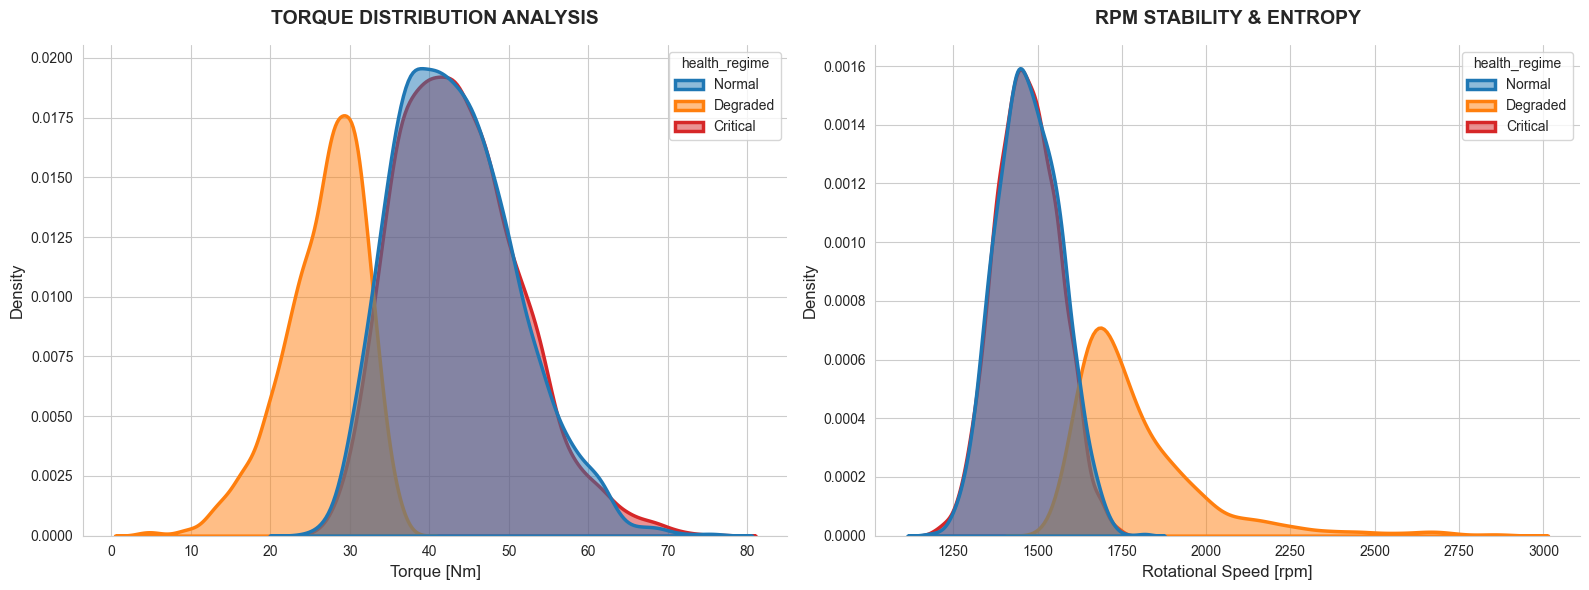

TECHNICAL INSIGHT:
The Normal (Blue) and Critical (Red) regimes show sharp, 'low-entropy' peaks.
The Degraded (Orange) regime shows a high-variance, 'high-entropy' distribution,
explaining the absence of deterministic association rules in that state.


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# PRESENTATION-GRADE ENTROPY VISUALIZATION
# ---------------------------------------------------------

# 1. Define high-contrast colors
# Blue = Normal, Orange = Degraded, Red = Critical
custom_palette = {"Normal": "#1f77b4", "Degraded": "#ff7f0e", "Critical": "#d62728"}

# 2. Set the aesthetic style
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Torque Distribution
sns.kdeplot(
    data=df, x='torque', hue='health_regime', 
    fill=True, palette=custom_palette, 
    alpha=0.5, linewidth=2.5, ax=axes[0]
)
axes[0].set_title('TORQUE DISTRIBUTION ANALYSIS', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Torque [Nm]', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)

# Plot 2: Rotational Speed Distribution
sns.kdeplot(
    data=df, x='rotational_speed', hue='health_regime', 
    fill=True, palette=custom_palette, 
    alpha=0.5, linewidth=2.5, ax=axes[1]
)
axes[1].set_title('RPM STABILITY & ENTROPY', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Rotational Speed [rpm]', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)

# Clean up the layout
sns.despine()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# TECHNICAL CAPTION FOR REPORT
# ---------------------------------------------------------
print("TECHNICAL INSIGHT:")
print("The Normal (Blue) and Critical (Red) regimes show sharp, 'low-entropy' peaks.")
print("The Degraded (Orange) regime shows a high-variance, 'high-entropy' distribution,")
print("explaining the absence of deterministic association rules in that state.")